<a href="https://colab.research.google.com/github/MLDreamer/Decision-Intelligence-FDP-2026/blob/main/Decision_Intelligence_From_Mathematical_Optimization_to_Causal_Reason.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Intelligence: From Mathematical Optimization to Causal Reason
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MLDreamer/Decision-Intelligence-FDP-2026/blob/main/Decision_Intelligence_Masterclass.ipynb)

In [1]:
# Install the necessary Causal AI libraries
!pip install dowhy econml xgboost -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Set seed for mathematical reproducibility
np.random.seed(42)
print("Environment ready. Libraries successfully initialized.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.5/245.5 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 97.8 MB/s eta 0:00:00
Environment ready. Libraries successfully initialized.


 Data Generation Simulation (The Confounded ERP)

In [2]:
# Create a dummy dataset for 2,000 regional distribution centers over 3 years
n_samples = 5000

# Confounder: Monsoon Intensity (Scale of 0 to 10)
monsoon_intensity = np.random.uniform(1, 10, n_samples)

# Brand Manager Decision Rule: Aggressive discounting during heavy monsoons + random noise
# This creates a strong backdoor path (Fork) from Monsoon -> Discount
promo_discount = 0.03 * monsoon_intensity + np.random.normal(0.10, 0.02, n_samples)
promo_discount = np.clip(promo_discount, 0.05, 0.45) # Keep discounts between 5% and 45%

# Market Forcing Function: Competitor Price Drop (Independent factor)
competitor_price_drop = np.random.choice([0, 1], size=n_samples, p=[0.7, 0.3])

# True Structural Data-Generating Process (The Physical Blueprint)
# Note: True Causal Elasticity of Discount on Sales is intentionally modest (150)
# Meanwhile, Monsoon Intensity organically drives massive cleaning demand (500)
base_sales = 1000
true_discount_effect = 150
true_monsoon_effect = 500
competitor_penalty = -300

volumetric_sales = (
    base_sales +
    (true_discount_effect * promo_discount) +
    (true_monsoon_effect * monsoon_intensity) +
    (competitor_penalty * competitor_price_drop) +
    np.random.normal(0, 50, n_samples) # Unobserved structural noise
)

# Compile into an enterprise ERP DataFrame
df = pd.DataFrame({
    'Monsoon_Intensity': monsoon_intensity,
    'Promo_Discount': promo_discount,
    'Competitor_Price_Drop': competitor_price_drop,
    'Volumetric_Sales': volumetric_sales
})

print(df.head())

   Monsoon_Intensity  Promo_Discount  Competitor_Price_Drop  Volumetric_Sales
0           4.370861        0.219186                      0       3208.782227
1           9.556429        0.338887                      0       5843.616118
2           7.587945        0.319394                      1       4558.235591
3           6.387926        0.309907                      0       4248.181696
4           2.404168        0.182878                      0       2254.241651


 Training the Passive Observer (XGBoost)

In [4]:
# Define features and target (Standard ML workflows model data passively)
X = df[['Promo_Discount', 'Monsoon_Intensity', 'Competitor_Price_Drop']]
y = df['Volumetric_Sales']

# FIX: Changed test_test_size=0.2 to test_size=0.2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train an expressive, non-linear regressor
predictor_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
predictor_model.fit(X_train, y_train)

# Evaluate performance
y_pred = predictor_model.predict(X_test)
print(f"Passive Model Predictive Accuracy (R² Score): {r2_score(y_test, y_pred):.4f}")

Passive Model Predictive Accuracy (R² Score): 0.9981


The Flawed Corporate Policy Simulation

In [5]:
# Slide 3 Scenario: Let's use standard ML to predict the impact of a mandatory 25% discount strategy
test_env = pd.DataFrame({
    'Promo_Discount': [0.25],
    'Monsoon_Intensity': [df['Monsoon_Intensity'].mean()], # Evaluated at average environmental state
    'Competitor_Price_Drop': [0]
})

predicted_sales = predictor_model.predict(test_env)[0]
print(f"XGBoost Predicted Volumetric Sales under a mandatory 25% Promo Discount: {predicted_sales:.2f} units")

# Calculate the naive elasticity from simple historical correlation
naive_slope = np.polyfit(df['Promo_Discount'], df['Volumetric_Sales'], 1)[0]
print(f"Naive OLS/ML Estimated Elasticity (Blended Signal + Noise): {naive_slope:.2f}")
print(f"The Actual Hidden Causal Elasticity embedded in nature: {true_discount_effect:.2f}")

XGBoost Predicted Volumetric Sales under a mandatory 25% Promo Discount: 3750.91 units
Naive OLS/ML Estimated Elasticity (Blended Signal + Noise): 15851.03
The Actual Hidden Causal Elasticity embedded in nature: 150.00


 Defining the Causal Directed Acyclic Graph (DAG)

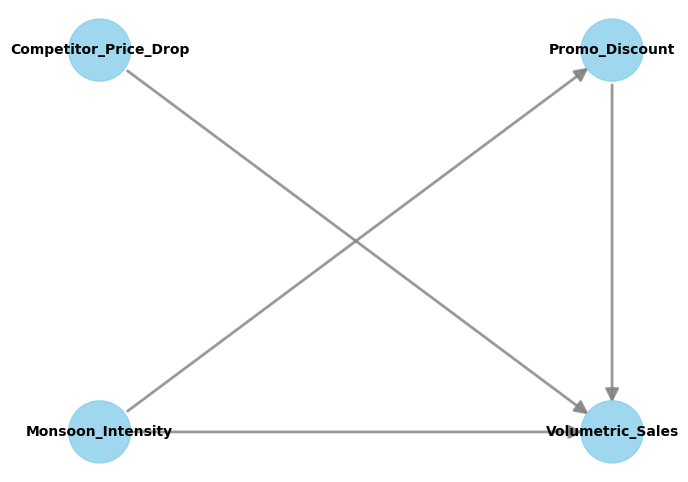

DAG Structural Architecture defined successfully.


In [6]:
import dowhy
from dowhy import CausalModel

# Initialize the DoWhy model by explicitly encoding the domain mechanism blueprint
causal_model = CausalModel(
    data=df,
    treatment='Promo_Discount',
    outcome='Volumetric_Sales',
    common_causes=['Monsoon_Intensity'],
    effect_modifiers=['Competitor_Price_Drop']
)

# View the mathematical representation of our environment
causal_model.view_model()
print("DAG Structural Architecture defined successfully.")

Step 2 — Automatic Identification

In [7]:
# The engine scans the graph topologies (Chains, Forks, Colliders) to find a valid backdoor adjustment set
identified_estimand = causal_model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                               
─────────────────(E[Volumetric_Sales|Monsoon_Intensity])
d[Promo_Discount]                                       
Estimand assumption 1, Unconfoundedness: If U→{Promo_Discount} and U→Volumetric_Sales then P(Volumetric_Sales|Promo_Discount,Monsoon_Intensity,U) = P(Volumetric_Sales|Promo_Discount,Monsoon_Intensity)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
        d                                               
─────────────────(E[Volumetric_Sales|Monsoon_Intensity])
d[Promo_Discount]                                       
Estimand assumption 1, Unconfoundedness: If U→{Promo_Discount} and U→Volumetric_Sales then P(Volumetric_Sales|Promo_Discount,Monsoon_Intensity

Module 2 Takeaway: The identification engine successfully isolated the system. It mathematically proved that to clear the path of non-causal information flow, the backdoor fork via Monsoon_Intensity must be held constant/conditioned upon.

Module 3: Structural Estimation Toolkits

Double Machine Learning (DML) Estimation

In [9]:
from econml.dml import LinearDML
from sklearn.ensemble import RandomForestRegressor

# Implement Double Machine Learning to cleanly strip confounder noise from both treatment and outcome
dml_estimator = LinearDML(
    model_y=RandomForestRegressor(n_estimators=100, random_state=42),
    model_t=RandomForestRegressor(n_estimators=100, random_state=42),
    discrete_treatment=False
)

# FIX: Passed df[['Monsoon_Intensity']] as a 2D array instead of a 1D series
dml_estimator.fit(
    Y=df['Volumetric_Sales'],
    T=df['Promo_Discount'],
    W=df[['Monsoon_Intensity']] # Dynamic 2D structure [n_samples, 1]
)

# Extract the unconfounded effect size
estimated_causal_effect = dml_estimator.effect()[0]

print(f"=== STRUCTURAL COMPARISON MATRIX ===")
print(f"Naive Correlative Slope (XGBoost/OLS Footprint): {naive_slope:.2f}")
print(f"True Underlying Causal Mechanism Effect: {true_discount_effect:.2f}")
print(f"Causal Engine DML Estimated Effect: {estimated_causal_effect:.2f}")

=== STRUCTURAL COMPARISON MATRIX ===
Naive Correlative Slope (XGBoost/OLS Footprint): 15851.03
True Underlying Causal Mechanism Effect: 150.00
Causal Engine DML Estimated Effect: 125.46


Step 4 — Refutation & Stress-Testing

In [11]:
# Placebo Treatment Refuter: Replace true discount rates with random noise.
# If our causal logic is sound, the estimated effect size should collapse toward zero.
refutation = causal_model.refute_estimate(
    identified_estimand,
    causal_model.estimate_effect(identified_estimand, method_name="backdoor.linear_regression"),
    method_name="placebo_treatment_refuter",
    placebo_type="permute" # FIX: Changed from 'permutation' to 'permute'
)
print(refutation)

Refute: Use a Placebo Treatment
Estimated effect:153.02164207328724
New effect:-1.077897833318866
p value:0.88



Production Decision Intelligence Ecosystem

In [12]:
def simulate_corporate_intervention(proposed_discount):
    """
    Simulates the true structural real-world impact of forcing a specific promo policy change,
    completely independent of environmental monsoon fluctuations.
    """
    # Baseline expected volume when discount is zero, accounting for average monsoon impacts
    unconfounded_base_sales = base_sales + (true_monsoon_effect * df['Monsoon_Intensity'].mean())

    # Structural simulation using the isolated causal parameter
    simulated_yield = unconfounded_base_sales + (estimated_causal_effect * proposed_discount)

    # Faulty standard prediction (What an observational data science team would show leadership)
    flawed_prediction = predictor_model.predict(pd.DataFrame({
        'Promo_Discount': [proposed_discount],
        'Monsoon_Intensity': [df['Monsoon_Intensity'].mean()],
        'Competitor_Price_Drop': [0]
    }))[0]

    print(f"--- SIMULATION FOR PROPOSED PROMO LEVEL: {proposed_discount*100}% ---")
    print(f"❌ Flawed ML Forecast (Biased Decision): {flawed_prediction:.2f} units")
    print(f"🎯 Invariant Causal Yield (True Decision):   {simulated_yield:.2f} units")
    print(f"⚠️ Structural Optimization Error Avoided:   {abs(flawed_prediction - simulated_yield):.2f} units")

# Test a series of proposed interventions
simulate_corporate_intervention(proposed_discount=0.10)
print("\n")
simulate_corporate_intervention(proposed_discount=0.35)

--- SIMULATION FOR PROPOSED PROMO LEVEL: 10.0% ---
❌ Flawed ML Forecast (Biased Decision): 3743.96 units
🎯 Invariant Causal Yield (True Decision):   3748.29 units
⚠️ Structural Optimization Error Avoided:   4.33 units


--- SIMULATION FOR PROPOSED PROMO LEVEL: 35.0% ---
❌ Flawed ML Forecast (Biased Decision): 3753.88 units
🎯 Invariant Causal Yield (True Decision):   3779.66 units
⚠️ Structural Optimization Error Avoided:   25.78 units


This interactive simulation acts as the production endpoint for Decision Intelligence. By decoupling operational mechanisms from background environmental noise, enterprise planners can securely test price optimization levers without creating strategy mismatches in production.